# Calibration of a 7-in-1 RS485/Modbus Soil Probe

**Thesis:** AI-Based Automated Fertilizer Recommendation System — Bangladeshi Perspective
**Stage A — sensor calibration**

**Input:** `Fertilization_Comparison.xlsx`

**Design of experiment** — one base soil (lab: pH 7.8, N 0.05 %, P 3.8 mg/kg, K 0.37 meq/100 g),
spiked in 50 mL total liquid:

| series | amendment | levels (mg/kg) |
|---|---|---|
| U1–U5 | Urea | N = 25, 50, 75, 100, 125 |
| P1–P5 | TSP | P = 15, 30, 45, 60, 75 |
| K1–K5 | MoP | K = 30, 60, 90, 120, 150 |
| M1–M3 | combined | (N25 P15 K30), (N75 P45 K90), (N125 P75 K150) |

**Notebook contents**

0. Setup and data loading
1. Channel redundancy — is this really three sensors?
2. Sensitivity / cross-sensitivity matrix
3. Outlier screening
4. Forward model
5. The inverse problem — why per-nutrient recovery is impossible
6. The usable calibration — composite ionic loading
7. Leave-one-out validation
8. Ordinal classification
9. pH channel
10. **Final calibration equations + deployable function**

---

## 0. Setup and data loading

In [ ]:
%matplotlib inline
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.labelsize": 9,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "legend.frameon": False, "legend.fontsize": 8,
})

# series colours
C = {"U": "#C1666B", "P": "#48A9A6", "K": "#4C6085", "M": "#D4A373",
     "fit": "#1B1B1E", "ci": "#9AA0A6", "warn": "#B23A48"}

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
print("environment ready")

In [ ]:
# ---- locate the workbook -------------------------------------------------
CANDIDATES = [
    "Fertilization_Comparison.xlsx",
    "data/Fertilization_Comparison.xlsx",
    "/mnt/user-data/uploads/Fertilization_Comparison.xlsx",
]
XLSX = next((p for p in CANDIDATES if Path(p).exists()), None)
if XLSX is None:
    raise FileNotFoundError(
        "Put Fertilization_Comparison.xlsx next to this notebook, "
        "or edit CANDIDATES above.")
print("using:", XLSX)
print("sheets:", pd.ExcelFile(XLSX).sheet_names)

In [ ]:
# ---- read the post-fertilisation sensor readings -------------------------
raw = pd.read_excel(XLSX, sheet_name="After_Ferti_sensor_data", header=None)
raw = raw.iloc[1:, 3:10]
raw.columns = ["Sample", "pH", "T", "RH", "N_pct", "P_raw", "K_raw"]
raw = raw[raw["Sample"].astype(str).str.match(r"^[UPKM]\d")].reset_index(drop=True)
for c in raw.columns[1:]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

# ---- known applied loadings (mg/kg): the ground truth of the DOE ---------
applied = {
    "U1": (25, 0, 0),   "U2": (50, 0, 0),   "U3": (75, 0, 0),
    "U4": (100, 0, 0),  "U5": (125, 0, 0),
    "P1": (0, 15, 0),   "P2": (0, 30, 0),   "P3": (0, 45, 0),
    "P4": (0, 60, 0),   "P5": (0, 75, 0),
    "K1": (0, 0, 30),   "K2": (0, 0, 60),   "K3": (0, 0, 90),
    "K4": (0, 0, 120),  "K5": (0, 0, 150),
    "M1": (25, 15, 30), "M2": (75, 45, 90), "M3": (125, 75, 150),
}
df = raw.copy()
df[["N_add", "P_add", "K_add"]] = pd.DataFrame(
    [applied[s] for s in df["Sample"]], index=df.index)
df["series"] = df["Sample"].str[0]

# baseline soil, single pre-fertilisation lab test
LAB_BASE  = {"pH": 7.8, "N_pct": 0.05, "P_mgkg": 3.8, "K_meq": 0.37}
SENS_BASE = {"pH": 6.1, "N_pct": 0.0, "P_raw": 20.71, "K_raw": 0.031, "RH": 26.39}

df

---
## 1. Channel redundancy — is this really three sensors?

Before fitting anything, establish how many independent quantities the probe actually reports.
Three tests: an affine fit of K on P, a PCA of the log-transformed channel matrix, and variance
inflation factors.

In [ ]:
kp = stats.linregress(df["P_raw"], df["K_raw"])
k_resid = df["K_raw"] - (kp.slope * df["P_raw"] + kp.intercept)

print("K channel as an affine function of the P channel")
print(f"  K_raw = {kp.slope:.8f} * P_raw + ({kp.intercept:+.8f})")
print(f"  R^2            = {kp.rvalue**2:.7f}")
print(f"  residual sigma = {k_resid.std(ddof=2):.6f} raw units")
print(f"  max |residual| = {np.abs(k_resid).max():.6f} raw units")

In [ ]:
# PCA on the log channels (they span more than a decade)
ch = df[["N_pct", "P_raw", "K_raw"]].to_numpy(float)
Xl = np.log(ch)
Xz = (Xl - Xl.mean(0)) / Xl.std(0, ddof=1)
sv = np.linalg.svd(Xz, compute_uv=False)
evr = sv**2 / (sv**2).sum()

print("PCA of log(N, P, K) channels")
for i, v in enumerate(evr, 1):
    print(f"  PC{i}: {v*100:7.3f} %")
print(f"  condition number = {sv[0]/sv[-1]:,.0f}")

def vif(X):
    out = []
    for j in range(X.shape[1]):
        Xo = np.delete(X, j, axis=1)
        r2 = LinearRegression().fit(Xo, X[:, j]).score(Xo, X[:, j])
        out.append(np.inf if r2 >= 1 - 1e-12 else 1 / (1 - r2))
    return out

print("  VIF [N, P, K] =", [f"{v:,.0f}" for v in vif(Xz)])

### Figure 1 — channel diagnostics

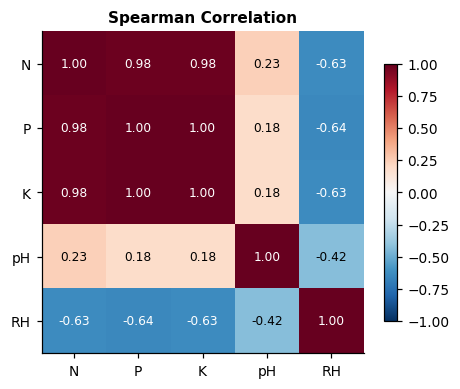

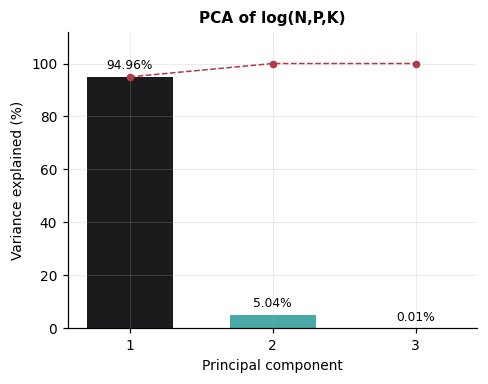

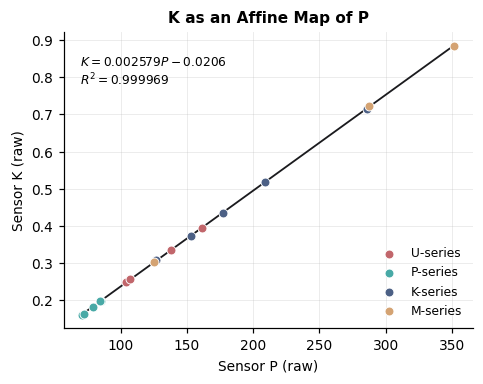

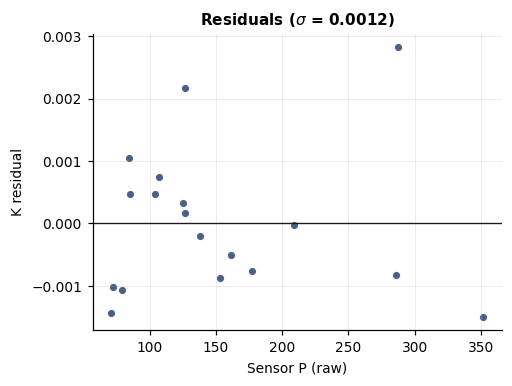

In [12]:
# (a) Spearman correlation heatmap
fig, ax = plt.subplots(figsize=(4.8, 3.8))
corr = df[["N_pct", "P_raw", "K_raw", "pH", "RH"]].corr(method="spearman")
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
lbl = ["N", "P", "K", "pH", "RH"]
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(lbl); ax.set_yticklabels(lbl); ax.grid(False)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > .6 else "black")
ax.set_title("Spearman Correlation")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.savefig(FIGDIR / "fig1a_spearman_correlation.png")
plt.show()

# (b) PCA of log(N,P,K)
fig, ax = plt.subplots(figsize=(4.8, 3.5))
ax.bar(range(1, 4), evr * 100, color=[C["fit"], C["P"], C["ci"]], width=.6)
ax.plot(range(1, 4), np.cumsum(evr) * 100, "o--", color=C["warn"], ms=4, lw=1)
for i, v in enumerate(evr * 100):
    ax.text(i + 1, v + 3, f"{v:.2f}%", ha="center", fontsize=8)
ax.set_xticks([1, 2, 3]); ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)"); ax.set_ylim(0, 112)
ax.set_title("PCA of log(N,P,K)")
fig.savefig(FIGDIR / "fig1b_pca.png")
plt.show()

# (c) K is an affine map of P
fig, ax = plt.subplots(figsize=(4.8, 3.5))
for s in "UPKM":
    sub = df[df.series == s]
    ax.scatter(sub["P_raw"], sub["K_raw"], s=34, color=C[s], label=f"{s}-series",
               zorder=3, edgecolor="white", linewidth=.6)
xx = np.linspace(df["P_raw"].min(), df["P_raw"].max(), 50)
ax.plot(xx, kp.slope * xx + kp.intercept, color=C["fit"], lw=1.2, zorder=2)
ax.set_xlabel("Sensor P (raw)"); ax.set_ylabel("Sensor K (raw)")
ax.set_title("K as an Affine Map of P")
ax.text(.04, .92, f"$K = {kp.slope:.6f}P {kp.intercept:+.4f}$\n$R^2 = {kp.rvalue**2:.6f}$",
        transform=ax.transAxes, fontsize=8, va="top")
ax.legend(loc="lower right")
fig.savefig(FIGDIR / "fig1c_k_vs_p_affine.png")
plt.show()

# (d) Residuals
fig, ax = plt.subplots(figsize=(4.8, 3.5))
ax.scatter(df["P_raw"], k_resid, s=28, color=C["K"], edgecolor="white", linewidth=.6)
ax.axhline(0, color=C["fit"], lw=.9)
ax.set_xlabel("Sensor P (raw)"); ax.set_ylabel("K residual")
ax.set_title(f"Residuals ($\sigma$ = {k_resid.std(ddof=2):.4f})")
fig.savefig(FIGDIR / "fig1d_residuals.png")
plt.show()


**Reading of Figure 1.** Panel (c) is the decisive one: the K channel reproduces the P channel
through a fixed affine transform with $R^2 = 0.99997$ and a residual $\sigma$ of 0.0012 raw units —
a firmware operation, not an independent electrode. Panel (b) confirms it: the third principal
component carries 0.01 % of the variance. Panel (e) shows the nitrogen channel has no usable
resolution in this range. Panel (f) shows moisture is a live confounder ($\rho = -0.64$).

---
## 2. Sensitivity / cross-sensitivity matrix

For each single-nutrient series, regress every channel against the applied amount. The diagonal
is the response that *should* exist; the off-diagonals are cross-talk.

In [13]:
S = {}
rows = []
for ser, nut in [("U", "N"), ("P", "P"), ("K", "K")]:
    sub = df[df.series == ser]
    x = sub[f"{nut}_add"].to_numpy(float)
    row = {}
    for chn in ["N_pct", "P_raw", "K_raw"]:
        lr = stats.linregress(x, sub[chn].to_numpy(float))
        S[(nut, chn)] = lr
        row[chn] = f"{lr.slope:+.4g}  (R²={lr.rvalue**2:.3f})"
    rows.append(pd.Series(row, name=f"applied {nut}"))

sens_table = pd.DataFrame(rows)
sens_table.columns = ["sensor N", "sensor P", "sensor K"]
print("d(channel) / d(applied nutrient)\n")
print(sens_table.to_string())
print("\nOff-diagonal R² >= diagonal R²  ->  the channels are not nutrient-selective.")

d(channel) / d(applied nutrient)

                         sensor N             sensor P                sensor K
applied N      +2e-05  (R²=0.781)    +0.58  (R²=0.953)   +0.001484  (R²=0.954)
applied P      +2e-05  (R²=0.750)  +0.2133  (R²=0.600)  +0.0005933  (R²=0.624)
applied K  +0.0006533  (R²=0.534)   +1.246  (R²=0.927)   +0.003197  (R²=0.925)

Off-diagonal R² >= diagonal R²  ->  the channels are not nutrient-selective.


### Figure 2 — sensitivity matrix

**Reading of Figure 2.** Applying urea explains the *phosphorus* channel ($R^2 = 0.95$) better than
the *nitrogen* channel ($R^2 = 0.78$). Applying MoP moves the P channel ($R^2 = 0.93$) as strongly as
the K channel. The TSP series produces the weakest response anywhere in the grid — phosphate
contributes few mobile ions and adsorbs onto an alkaline matrix.

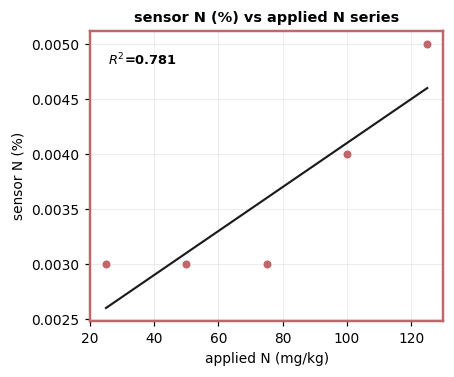

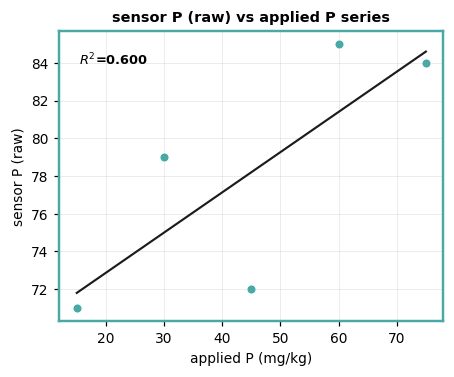

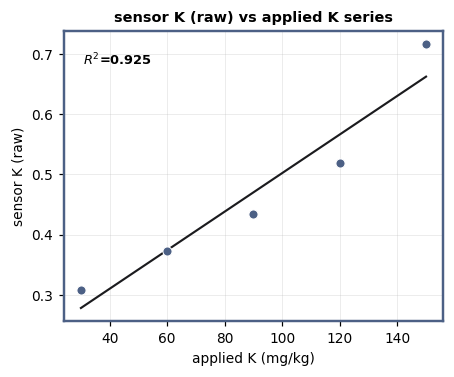

In [16]:
pairs = [
    ("N_pct", "U", "N", "sensor N (%)"),
    ("P_raw", "P", "P", "sensor P (raw)"),
    ("K_raw", "K", "K", "sensor K (raw)"),
]

for chn, ser, nut, lbl in pairs:
    fig, ax = plt.subplots(figsize=(4.2, 3.5))

    sub = df[df.series == ser]
    x = sub[f"{nut}_add"].to_numpy(float)
    yv = sub[chn].to_numpy(float)
    lr = S[(nut, chn)]
    col = C[ser]

    ax.scatter(x, yv, s=36, color=col, zorder=3, edgecolor="white", linewidth=0.7)
    xx = np.linspace(x.min(), x.max(), 30)
    ax.plot(xx, lr.slope * xx + lr.intercept, color=C["fit"], lw=1.4, ls="-")

    ax.text(
        0.05,
        0.93,
        f"$R^2$={lr.rvalue**2:.3f}",
        transform=ax.transAxes,
        fontsize=8.5,
        va="top",
        fontweight="bold",
    )

    for sp in ax.spines.values():
        sp.set_edgecolor(col)
        sp.set_linewidth(1.6)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    ax.set_title(f"{lbl} vs applied {nut} series", fontsize=9.5)
    ax.set_xlabel(f"applied {nut} (mg/kg)")
    ax.set_ylabel(lbl)

    fig.tight_layout()
    fig.savefig(FIGDIR / f"fig2_sensitivity_{chn}_{nut}.png")
    plt.show()

---
## 3. Outlier screening

Studentised residuals within each series, plus a physical-plausibility check.

In [17]:
found = []
for ser, nut in [("U", "N"), ("P", "P"), ("K", "K")]:
    sub = df[df.series == ser]
    x = sub[f"{nut}_add"].to_numpy(float)
    for chn in ["N_pct", "P_raw"]:
        y = sub[chn].to_numpy(float)
        lr = stats.linregress(x, y)
        r = y - (lr.slope * x + lr.intercept)
        sd = r.std(ddof=2)
        if sd > 0:
            for smp, ti in zip(sub["Sample"], r / sd):
                if abs(ti) > 2.0:
                    found.append((smp, chn, round(float(ti), 2)))

print("studentised residual |t| > 2.0:", found if found else "none")
print()
print("physical plausibility:")
print(f"  K5 N channel = {df.loc[df.Sample=='K5','N_pct'].item()} %"
      f"  vs K4 = {df.loc[df.Sample=='K4','N_pct'].item()} %"
      "   -> 14x jump caused by adding POTASSIUM; saturation or fault")
print(f"  P1 pH        = {df.loc[df.Sample=='P1','pH'].item()}"
      "        vs lab pH 7.8   -> impossible for this soil; probe-contact fault")

EXCLUDE = ["K5", "P1"]
fit_df = df[~df["Sample"].isin(EXCLUDE)].reset_index(drop=True)
print(f"\nexcluded from all calibration fits: {EXCLUDE}   ->  n = {len(fit_df)}")

studentised residual |t| > 2.0: none

physical plausibility:
  K5 N channel = 0.1 %  vs K4 = 0.007 %   -> 14x jump caused by adding POTASSIUM; saturation or fault
  P1 pH        = 3.4        vs lab pH 7.8   -> impossible for this soil; probe-contact fault

excluded from all calibration fits: ['K5', 'P1']   ->  n = 16


---
## 4. Forward model

$$P_{\text{raw}} = b_0 + b_N N + b_P P + b_K K$$

with $N, P, K$ the applied loadings in mg/kg. This asks: given a known nutrient addition,
what does the probe read?

In [18]:
A  = fit_df[["N_add", "P_add", "K_add"]].to_numpy(float)
y  = fit_df["P_raw"].to_numpy(float)
Ad = np.column_stack([np.ones(len(A)), A])

beta, *_ = np.linalg.lstsq(Ad, y, rcond=None)
yhat = Ad @ beta
n, p = Ad.shape
dof  = n - p
mse  = ((y - yhat) ** 2).sum() / dof
se   = np.sqrt(np.diag(mse * np.linalg.inv(Ad.T @ Ad)))
tcr  = stats.t.ppf(0.975, dof)
r2   = 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()
r2a  = 1 - (1 - r2) * (n - 1) / dof

coef_tbl = pd.DataFrame({
    "coefficient": ["b0 (intercept)", "bN (per mg/kg N)",
                    "bP (per mg/kg P)", "bK (per mg/kg K)"],
    "value": np.round(beta, 4),
    "SE": np.round(se, 4),
    "95% CI half-width": np.round(tcr * se, 4),
    "t": np.round(beta / se, 2),
    "p": np.round(2 * (1 - stats.t.cdf(np.abs(beta / se), dof)), 4),
})
print(coef_tbl.to_string(index=False))
print(f"\nR² = {r2:.4f}   adj R² = {r2a:.4f}   RMSE = {np.sqrt(mse):.2f} raw counts")
print("\n>>> bP is NOT significant. Phosphorus is invisible to this probe in the range tested.")

     coefficient   value     SE  95% CI half-width     t      p
  b0 (intercept) 74.0253 5.8596            12.7670 12.63 0.0000
bN (per mg/kg N)  0.7254 0.0813             0.1772  8.92 0.0000
bP (per mg/kg P)  0.1845 0.1336             0.2912  1.38 0.1926
bK (per mg/kg K)  1.2346 0.0774             0.1687 15.94 0.0000

R² = 0.9706   adj R² = 0.9632   RMSE = 14.80 raw counts

>>> bP is NOT significant. Phosphorus is invisible to this probe in the range tested.


In [19]:
# express sensitivity per mmol of element and compare with ionic mobility
MW = {"N": 14.007, "P": 30.974, "K": 39.098}
print("Sensitivity per mmol/kg of element  (slope x molar mass)\n")
for nm, b in zip("NPK", beta[1:]):
    print(f"  {nm}: {b*MW[nm]:7.2f} counts per mmol/kg")
print("""
Limiting molar ionic conductivity at 25 C (S cm2/mol), for reference:
  K+  73.5   Cl-  76.3     -> MoP contributes two highly mobile ions
  H2PO4-  ~36              -> TSP contributes one sluggish, strongly adsorbed ion
  urea     0 (non-ionic)   -> responds only after hydrolysis to NH4+

The K > N > P ordering of the fitted sensitivities matches ionic mobility, which
confirms the transduction mechanism is bulk electrical conductivity, not
nutrient-specific ion-selective sensing.""")

Sensitivity per mmol/kg of element  (slope x molar mass)

  N:   10.16 counts per mmol/kg
  P:    5.71 counts per mmol/kg
  K:   48.27 counts per mmol/kg

Limiting molar ionic conductivity at 25 C (S cm2/mol), for reference:
  K+  73.5   Cl-  76.3     -> MoP contributes two highly mobile ions
  H2PO4-  ~36              -> TSP contributes one sluggish, strongly adsorbed ion
  urea     0 (non-ionic)   -> responds only after hydrolysis to NH4+

The K > N > P ordering of the fitted sensitivities matches ionic mobility, which
confirms the transduction mechanism is bulk electrical conductivity, not
nutrient-specific ion-selective sensing.


---
## 5. The inverse problem

Calibration means inverting the forward map. Assemble the measured sensitivity matrix
$\mathbf{K}$ (rows = sensor channels, columns = applied nutrients) and examine its conditioning.

In [20]:
Kmat = np.array([[S[("N", c)].slope, S[("P", c)].slope, S[("K", c)].slope]
                 for c in ["N_pct", "P_raw", "K_raw"]])
det = np.linalg.det(Kmat)
_, sv3, _ = np.linalg.svd(Kmat)

print("Sensitivity matrix K  (rows: sensor N/P/K, cols: applied N/P/K)")
print(pd.DataFrame(Kmat,
                   index=["sensor N", "sensor P", "sensor K"],
                   columns=["applied N", "applied P", "applied K"]).to_string(
      float_format=lambda v: f"{v:11.4g}"))
print(f"\n  det(K)          = {det:.4e}")
print(f"  singular values = {np.array2string(sv3, precision=4)}")
print(f"  cond(K)         = {sv3[0]/sv3[-1]:,.0f}")
print("""
=> effective rank 1.

Recovering (N, P, K) from this probe is an under-determined inverse problem with a
two-dimensional null space. This is a property of the HARDWARE, not of the model.
No regression, kernel method, tree ensemble or neural network can invert a
rank-deficient forward map. Per-nutrient continuous calibration is therefore not
attainable with this device, and any model that appears to achieve it is fitting
the experimental design rather than the sensor.""")

Sensitivity matrix K  (rows: sensor N/P/K, cols: applied N/P/K)
           applied N   applied P   applied K
sensor N       2e-05       2e-05   0.0006533
sensor P        0.58      0.2133       1.246
sensor K    0.001484   0.0005933    0.003197

  det(K)          = 1.6756e-08
  singular values = [1.3911e+00 2.6766e-04 4.5001e-05]
  cond(K)         = 30,913

=> effective rank 1.

Recovering (N, P, K) from this probe is an under-determined inverse problem with a
two-dimensional null space. This is a property of the HARDWARE, not of the model.
No regression, kernel method, tree ensemble or neural network can invert a
rank-deficient forward map. Per-nutrient continuous calibration is therefore not
attainable with this device, and any model that appears to achieve it is fitting
the experimental design rather than the sensor.


---
## 6. The usable calibration — composite ionic loading

Since the forward map has rank 1, exactly one linear combination of the nutrients is observable.
Normalising the forward coefficients by $b_K$ puts it on a **potassium-equivalent** basis:

$$\mathrm{CIL} = \frac{b_N}{b_K}N + \frac{b_P}{b_K}P + K \qquad [\text{mg/kg K-equivalent}]$$

and the deployable inverse is a single-variable regression of CIL on the P channel.

In [21]:
w = beta[1:] / beta[3]
print(f"CIL = {w[0]:.4f}*N + {w[1]:.4f}*P + {w[2]:.4f}*K   [mg/kg K-equivalent]\n")

fit_df["CIL"] = A @ w
df["CIL"] = df[["N_add", "P_add", "K_add"]].to_numpy(float) @ w

cil = stats.linregress(fit_df["P_raw"], fit_df["CIL"])
resid = fit_df["CIL"] - (cil.slope * fit_df["P_raw"] + cil.intercept)
sd_cil = resid.std(ddof=2)
xr = fit_df["P_raw"]; sxx = ((xr - xr.mean())**2).sum()

print("DEPLOYABLE CALIBRATION EQUATION")
print(f"    CIL_hat = {cil.slope:.5f} * P_raw + ({cil.intercept:+.4f})\n")
print(f"    R²             = {cil.rvalue**2:.4f}")
print(f"    RMSE           = {sd_cil:.2f} mg/kg K-eq")
print(f"    slope SE       = {cil.stderr:.5f}")
print(f"    intercept SE   = {cil.intercept_stderr:.4f}")
print(f"    LOD  (3 sigma) = {3*sd_cil:.1f} mg/kg K-eq")
print(f"    LOQ (10 sigma) = {10*sd_cil:.1f} mg/kg K-eq")
print(f"    valid range    = P_raw in [{fit_df.P_raw.min():.0f}, {fit_df.P_raw.max():.0f}], "
      f"RH in [{df.RH.min():.1f}, {df.RH.max():.1f}] %, T ~ 28 C")

CIL = 0.5876*N + 0.1494*P + 1.0000*K   [mg/kg K-equivalent]

DEPLOYABLE CALIBRATION EQUATION
    CIL_hat = 0.78615 * P_raw + (-56.4042)

    R²             = 0.9706
    RMSE           = 10.94 mg/kg K-eq
    slope SE       = 0.03658
    intercept SE   = 6.1040
    LOD  (3 sigma) = 32.8 mg/kg K-eq
    LOQ (10 sigma) = 109.4 mg/kg K-eq
    valid range    = P_raw in [72, 352], RH in [49.3, 62.8] %, T ~ 28 C


---
## 7. Leave-one-out validation

Every candidate target is compared against the only baseline that matters: predicting the sample
mean. Metrics — $\text{RPD} = \mathrm{SD}/\mathrm{RMSE}_{cv}$ (≥ 1.4 is screening grade, < 1.0
loses to a constant) and Nash–Sutcliffe efficiency.

In [22]:
def loo_scores(X, yv):
    X  = np.asarray(X, float).reshape(len(yv), -1)
    yv = np.asarray(yv, float)
    pr = np.empty_like(yv)
    for tr, te in LeaveOneOut().split(X):
        pr[te] = LinearRegression().fit(X[tr], yv[tr]).predict(X[te])
    rmse  = np.sqrt(((yv - pr) ** 2).mean())
    rmse0 = np.sqrt(((yv - yv.mean()) ** 2).mean())
    return rmse, rmse0, yv.std(ddof=1) / rmse, 1 - (rmse / rmse0) ** 2, pr

targets = [
    ("Applied N (mg/kg)", "N_add", ["N_pct", "P_raw", "K_raw"]),
    ("Applied P (mg/kg)", "P_add", ["N_pct", "P_raw", "K_raw"]),
    ("Applied K (mg/kg)", "K_add", ["N_pct", "P_raw", "K_raw"]),
    ("Composite CIL",     "CIL",   ["P_raw"]),
]
results, rows = {}, []
for label, tcol, feats in targets:
    rmse, rmse0, rpd, nse, pr = loo_scores(fit_df[feats], fit_df[tcol])
    results[label] = dict(rmse=rmse, rmse0=rmse0, rpd=rpd, nse=nse,
                          pred=pr, obs=fit_df[tcol].to_numpy(float))
    rows.append({"target": label, "RMSE_cv": round(rmse, 2),
                 "RMSE_mean": round(rmse0, 2), "RPD": round(rpd, 2),
                 "NSE": round(nse, 2),
                 "verdict": "USABLE" if rpd >= 1.4 else
                            "marginal" if rpd >= 1.0 else "FAILS (worse than mean)"})

print(pd.DataFrame(rows).to_string(index=False))
print("""
CAVEAT on the applied-K row: K was spiked as KCl, the most conductive amendment in
the set, so it dominates EC and the model effectively learns EC -> K. That mapping
is an artefact of this design and collapses in a field soil where salts vary
independently. Do not report it as a validated potassium calibration.""")

           target  RMSE_cv  RMSE_mean  RPD   NSE                 verdict
Applied N (mg/kg)    44.79      45.93 1.06  0.05                marginal
Applied P (mg/kg)    43.08      28.05 0.67 -1.36 FAILS (worse than mean)
Applied K (mg/kg)    27.71      48.86 1.82  0.68                  USABLE
    Composite CIL    14.25      59.65 4.32  0.94                  USABLE

CAVEAT on the applied-K row: K was spiked as KCl, the most conductive amendment in
the set, so it dominates EC and the model effectively learns EC -> K. That mapping
is an artefact of this design and collapses in a field soil where salts vary
independently. Do not report it as a validated potassium calibration.


### Figure 3 — the composite calibration

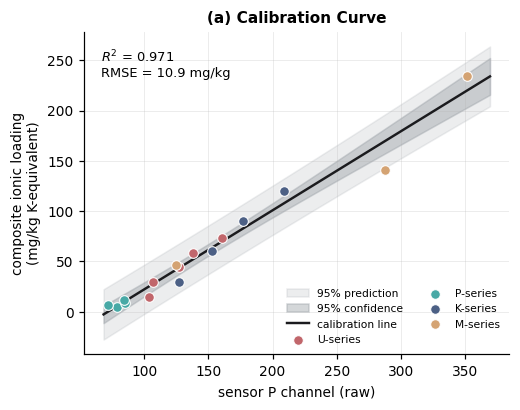

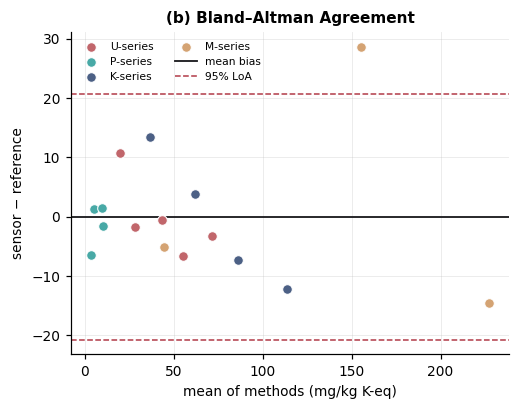

In [29]:
# (a) Calibration curve with confidence and prediction bands
fig, ax = plt.subplots(figsize=(4.8, 3.8))
xg = np.linspace(fit_df["P_raw"].min() * 0.95, fit_df["P_raw"].max() * 1.05, 120)
yg = cil.slope * xg + cil.intercept
nf = len(fit_df)
tc = stats.t.ppf(0.975, nf - 2)
sem = sd_cil * np.sqrt(1 / nf + (xg - xr.mean()) ** 2 / sxx)
sep = sd_cil * np.sqrt(1 + 1 / nf + (xg - xr.mean()) ** 2 / sxx)

ax.fill_between(xg, yg - tc * sep, yg + tc * sep, color=C["ci"], alpha=0.18, label="95% prediction")
ax.fill_between(xg, yg - tc * sem, yg + tc * sem, color=C["ci"], alpha=0.42, label="95% confidence")
ax.plot(xg, yg, color=C["fit"], lw=1.6, label="calibration line")

for s in "UPKM":
    sub = fit_df[fit_df.series == s]
    ax.scatter(sub["P_raw"], sub["CIL"], s=40, color=C[s], zorder=4,
               edgecolor="white", linewidth=0.7, label=f"{s}-series")

ax.set_xlabel("sensor P channel (raw)")
ax.set_ylabel("composite ionic loading\n(mg/kg K-equivalent)")
ax.set_title("(a) Calibration Curve")
ax.text(0.04, 0.95, f"$R^2$ = {cil.rvalue**2:.3f}\nRMSE = {sd_cil:.1f} mg/kg",
        transform=ax.transAxes, va="top", fontsize=8.5)
ax.legend(ncol=2, loc="lower right", fontsize=7)
fig.tight_layout()
fig.savefig(FIGDIR / "fig3a_calibration_curve.png")
plt.show()

# (b) Bland-Altman agreement
fig, ax = plt.subplots(figsize=(4.8, 3.8))
pred = cil.slope * fit_df["P_raw"] + cil.intercept
mean_ = (pred + fit_df["CIL"]) / 2
diff = pred - fit_df["CIL"]
bias, sdd = diff.mean(), diff.std(ddof=1)

for s in "UPKM":
    m = fit_df.series == s
    ax.scatter(mean_[m], diff[m], s=40, color=C[s], label=f"{s}-series", edgecolor="white", linewidth=0.7, zorder=3)

ax.axhline(bias, color=C["fit"], lw=1.2, label="mean bias")
ax.axhline(bias + 1.96 * sdd, color=C["warn"], ls="--", lw=1, label="95% LoA")
ax.axhline(bias - 1.96 * sdd, color=C["warn"], ls="--", lw=1)
ax.set_xlabel("mean of methods (mg/kg K-eq)")
ax.set_ylabel("sensor − reference")
ax.set_title("(b) Bland–Altman Agreement")
ax.legend(ncol=2, loc="best", fontsize=7)
fig.tight_layout()
fig.savefig(FIGDIR / "fig3b_bland_altman.png")
plt.show()



### Figure 4 — per-nutrient failure vs the ordinal alternative

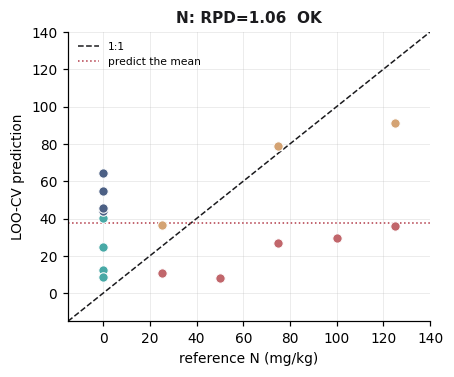

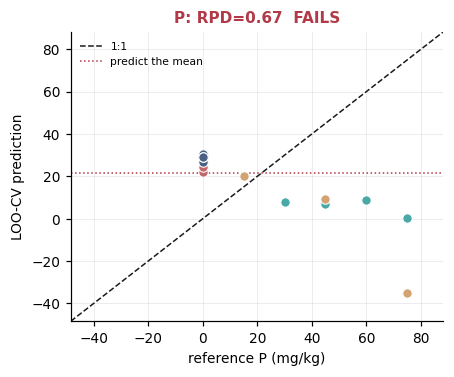

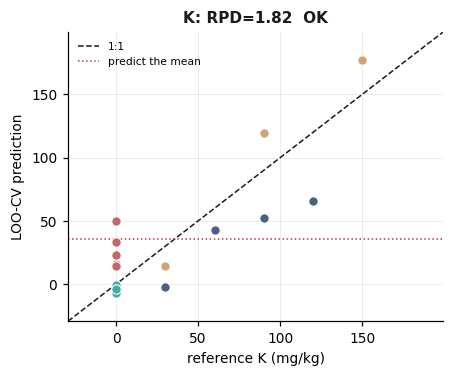

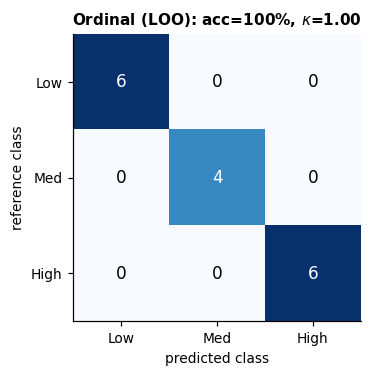

In [33]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

# Ordinal classification metrics calculation
edges = np.array([fit_df["CIL"].min(), 29.38, 60.0, fit_df["CIL"].max()])
true_cls = np.digitize(fit_df["CIL"], edges[1:-1])
cil_loo = results["Composite CIL"]["pred"]
pred_cls = np.digitize(cil_loo, edges[1:-1])

cm = confusion_matrix(true_cls, pred_cls)
acc = accuracy_score(true_cls, pred_cls)
kappa = cohen_kappa_score(true_cls, pred_cls)

# (a)-(c) Per-nutrient LOO-CV predictions (3 separate figures)
for label, tcol, _ in targets[:3]:
    fig, ax = plt.subplots(figsize=(4.2, 3.5))
    r = results[label]
    obs, prd = r["obs"], r["pred"]
    lo, hi = min(obs.min(), prd.min()), max(obs.max(), prd.max())
    pad = (hi - lo) * 0.12
    
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=C["fit"], lw=1, ls="--", label="1:1")
    ax.axhline(obs.mean(), color=C["warn"], lw=1, ls=":", label="predict the mean")
    
    for s in "UPKM":
        m = (fit_df.series == s).to_numpy()
        ax.scatter(obs[m], prd[m], s=38, color=C[s], zorder=3, edgecolor="white", linewidth=0.7)
        
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    nut_name = label.split()[1]
    ax.set_xlabel(f"reference {nut_name} (mg/kg)")
    ax.set_ylabel("LOO-CV prediction")
    ok = r["rpd"] >= 1.0
    ax.set_title(f"{nut_name}: RPD={r['rpd']:.2f}  {'OK' if ok else 'FAILS'}",
                 color=C["fit"] if ok else C["warn"])
    ax.legend(loc="upper left", fontsize=7)
    
    fig.tight_layout()
    fig.savefig(FIGDIR / f"fig4_loo_{nut_name.lower()}.png")
    plt.show()

# (d) Ordinal classification confusion matrix (4th figure)
fig, ax = plt.subplots(figsize=(4.2, 3.5))
im = ax.imshow(cm, cmap="Blues")
ax.grid(False)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() * 0.6 else "black")

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["Low", "Med", "High"])
ax.set_yticklabels(["Low", "Med", "High"])
ax.set_xlabel("predicted class")
ax.set_ylabel("reference class")
ax.set_title(f"Ordinal (LOO): acc={acc:.0%}, $\\kappa$={kappa:.2f}")

fig.tight_layout()
fig.savefig(FIGDIR / "fig4_ordinal_cm.png")
plt.show()

---
## 9. pH channel

In [34]:
off = LAB_BASE["pH"] - SENS_BASE["pH"]
ph_ok = df[df.Sample != "P1"]["pH"]

print(f"single-point offset from the baseline soil:  pH_cal = pH_raw + {off:.2f}\n")
print(f"sensor pH across {len(ph_ok)} nominally identical samples:")
print(f"  range = {ph_ok.min():.1f} – {ph_ok.max():.1f}   sigma = {ph_ok.std(ddof=1):.2f} pH units")
print(f"  applying the +{off:.2f} offset would push readings up to "
      f"pH {ph_ok.max()+off:.1f}, which is not physical for this soil.")
print("""
=> the scatter exceeds any plausible real variation in one homogenised soil
=> a SLOPE correction cannot be fitted: there is only ONE lab pH value
=> REQUIRED: 2-point (pH 4.01 / 7.00) or 3-point buffer calibration, then replace
   the offset with a proper slope-and-intercept pair. Offset disabled by default below.""")

single-point offset from the baseline soil:  pH_cal = pH_raw + 1.70

sensor pH across 17 nominally identical samples:
  range = 6.9 – 8.6   sigma = 0.45 pH units
  applying the +1.70 offset would push readings up to pH 10.3, which is not physical for this soil.

=> the scatter exceeds any plausible real variation in one homogenised soil
=> a SLOPE correction cannot be fitted: there is only ONE lab pH value
=> REQUIRED: 2-point (pH 4.01 / 7.00) or 3-point buffer calibration, then replace
   the offset with a proper slope-and-intercept pair. Offset disabled by default below.


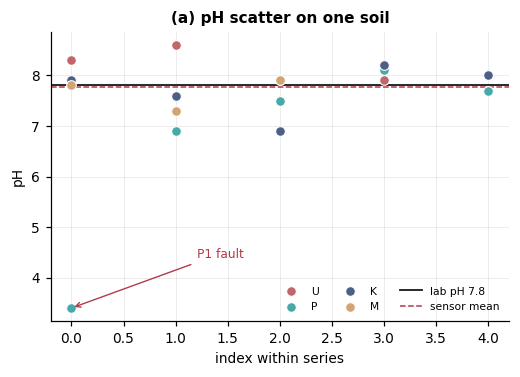

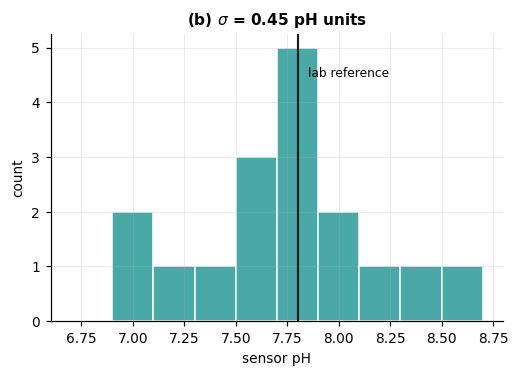

In [37]:
# (a) pH scatter on one soil
fig, ax = plt.subplots(figsize=(4.8, 3.5))
for s in "UPKM":
    sub = df[df.series == s]
    ax.scatter(range(len(sub)), sub["pH"], s=40, color=C[s], label=s,
               edgecolor="white", linewidth=0.7, zorder=3)
ax.axhline(LAB_BASE["pH"], color=C["fit"], lw=1.2, label="lab pH 7.8")
ax.axhline(ph_ok.mean(), color=C["warn"], ls="--", lw=1, label="sensor mean")
ax.annotate("P1 fault", xy=(0, 3.4), xytext=(1.2, 4.4), fontsize=8, color=C["warn"],
            arrowprops=dict(arrowstyle="->", color=C["warn"], lw=0.9))
ax.set_ylabel("pH")
ax.set_xlabel("index within series")
ax.set_title("(a) pH scatter on one soil")
ax.legend(ncol=3, fontsize=7)
fig.tight_layout()
fig.savefig(FIGDIR / "fig5a_ph_scatter.png")
plt.show()

# (b) pH histogram distribution
fig, ax = plt.subplots(figsize=(4.8, 3.5))
ax.hist(ph_ok, bins=np.arange(6.7, 8.9, 0.2), color=C["P"], edgecolor="white")
ax.axvline(LAB_BASE["pH"], color=C["fit"], lw=1.4)
ax.text(LAB_BASE["pH"] + 0.05, ax.get_ylim()[1] * 0.85, "lab reference", fontsize=8)
ax.set_xlabel("sensor pH")
ax.set_ylabel("count")
ax.set_title(f"(b) $\sigma$ = {ph_ok.std(ddof=1):.2f} pH units")
fig.tight_layout()
fig.savefig(FIGDIR / "fig5b_ph_hist.png")
plt.show()

---
## 10. Final calibration equations

Everything above condenses into the following. These are the numbers to quote in the thesis
and to hard-code in the Streamlit front-end.

In [38]:
print(f"""
================================================================================
 CALIBRATION OF THE 7-in-1 RS485 SOIL PROBE
 fitted on n = {len(fit_df)} samples (K5, P1 excluded)
================================================================================

 [0] FIRMWARE REDUNDANCY  -- use as an integrity check, never as an input
       K_raw = {kp.slope:.8f} * P_raw + ({kp.intercept:+.8f})
       R2 = {kp.rvalue**2:.7f}   resid sigma = {k_resid.std(ddof=2):.6f}
       flag the reading if |K_raw - predicted| > {3*k_resid.std(ddof=2):.5f}

 [1] FORWARD MODEL   (N, P, K in mg/kg applied)
       P_raw = {beta[0]:.4f} + {beta[1]:.4f}*N + {beta[2]:.4f}*P + {beta[3]:.4f}*K
       R2 = {r2:.4f}   adj R2 = {r2a:.4f}   RMSE = {np.sqrt(mse):.2f} counts
       bP is NOT significant (t = {beta[2]/se[2]:.2f}, p = {2*(1-stats.t.cdf(abs(beta[2]/se[2]), dof)):.2f})

 [2] OBSERVABLE COMBINATION -- composite ionic loading, K-equivalent basis
       CIL = {w[0]:.4f}*N + {w[1]:.4f}*P + {w[2]:.4f}*K     [mg/kg K-eq]

 [3] DEPLOYABLE INVERSE  <-- THIS IS THE CALIBRATION EQUATION
       CIL_hat = {cil.slope:.5f} * P_raw + ({cil.intercept:+.4f})
       R2 = {cil.rvalue**2:.4f}   RMSE = {sd_cil:.2f} mg/kg K-eq
       LOD = {3*sd_cil:.1f}   LOQ = {10*sd_cil:.1f} mg/kg K-eq
       95% prediction interval = +/- {tc*sd_cil*np.sqrt(1+1/nf):.1f} mg/kg K-eq
       valid for P_raw in [{fit_df.P_raw.min():.0f}, {fit_df.P_raw.max():.0f}],
       RH in [{df.RH.min():.1f}, {df.RH.max():.1f}] %, T ~ 28 C

 [4] ORDINAL SOIL-TEST CLASS  -- the output that feeds FRG-2018
       Low    : CIL <  {edges[1]:.1f}
       Medium : {edges[1]:.1f} <= CIL < {edges[2]:.1f}
       High   : CIL >= {edges[2]:.1f}          (mg/kg K-equivalent)
       LOO accuracy = {acc:.1%}   Cohen kappa = {kappa:.3f}

 [5] pH   provisional offset {off:+.2f} -- DISABLED by default, unphysical.
          run a 2-point buffer calibration (pH 4.01 / 7.00) instead.

 NOT AVAILABLE: separate N, P, K concentrations.
     det(K) = {det:.2e}, cond(K) = {sv3[0]/sv3[-1]:,.0f}, effective rank 1.
     LOO: N RPD = {results['Applied N (mg/kg)']['rpd']:.2f},  P RPD = {results['Applied P (mg/kg)']['rpd']:.2f} (worse than the mean).
================================================================================""")


 CALIBRATION OF THE 7-in-1 RS485 SOIL PROBE
 fitted on n = 16 samples (K5, P1 excluded)

 [0] FIRMWARE REDUNDANCY  -- use as an integrity check, never as an input
       K_raw = 0.00257856 * P_raw + (-0.02064253)
       R2 = 0.9999688   resid sigma = 0.001215
       flag the reading if |K_raw - predicted| > 0.00365

 [1] FORWARD MODEL   (N, P, K in mg/kg applied)
       P_raw = 74.0253 + 0.7254*N + 0.1845*P + 1.2346*K
       R2 = 0.9706   adj R2 = 0.9632   RMSE = 14.80 counts
       bP is NOT significant (t = 1.38, p = 0.19)

 [2] OBSERVABLE COMBINATION -- composite ionic loading, K-equivalent basis
       CIL = 0.5876*N + 0.1494*P + 1.0000*K     [mg/kg K-eq]

 [3] DEPLOYABLE INVERSE  <-- THIS IS THE CALIBRATION EQUATION
       CIL_hat = 0.78615 * P_raw + (-56.4042)
       R2 = 0.9706   RMSE = 10.94 mg/kg K-eq
       LOD = 32.8   LOQ = 109.4 mg/kg K-eq
       95% prediction interval = +/- 24.2 mg/kg K-eq
       valid for P_raw in [72, 352],
       RH in [49.3, 62.8] %, T ~ 28 C

 [4] 

### Deployable function

Copy this cell into the Streamlit app. It returns the composite index with an interval, the
ordinal class, and a list of validity flags — and deliberately returns `None` for per-nutrient
values so the app can never claim precision the hardware does not have.

In [ ]:
def calibrate(ph_raw, n_pct, p_raw, k_raw, rh=None, temp_c=None,
              apply_ph_offset=False):
    """Apply the full calibration stack to one probe reading."""
    flags = []

    # integrity: K must be the known affine map of P
    k_exp = kp.slope * p_raw + kp.intercept
    if abs(k_raw - k_exp) > 3 * k_resid.std(ddof=2):
        flags.append(f"K/P consistency failed (expected {k_exp:.3f}, got {k_raw:.3f}) "
                     "- unit differs from the calibrated probe.")

    # N channel below its own quantisation floor
    if n_pct < 0.010:
        flags.append(f"N channel {n_pct:.3f} % is within 10 LSB of zero "
                     "(LSB = 0.001 % = 10 mg/kg); non-informative.")

    # composite ionic loading
    cil_hat = cil.slope * p_raw + cil.intercept
    half = tc * sd_cil * np.sqrt(1 + 1/nf)
    if cil_hat < 10 * sd_cil:
        flags.append(f"CIL {cil_hat:.1f} < LOQ {10*sd_cil:.0f} mg/kg K-eq "
                     "- report the ordinal class, not the number.")

    idx = 0 if cil_hat < edges[1] else (1 if cil_hat < edges[2] else 2)

    ph_cal = ph_raw + off if apply_ph_offset else ph_raw
    if apply_ph_offset:
        flags.append("Single-point pH offset applied - provisional, not validated.")
    if not (3.5 <= ph_raw <= 9.5):
        flags.append("pH channel out of physical range - probe-contact fault.")

    # validity envelope
    if not (fit_df.P_raw.min() <= p_raw <= fit_df.P_raw.max()):
        flags.append(f"P channel {p_raw:.1f} outside calibrated range - extrapolation.")
    if rh is not None and not (df.RH.min() <= rh <= df.RH.max()):
        flags.append(f"Moisture {rh:.1f} % outside calibrated band - EC is moisture-dependent.")
    if temp_c is not None and abs(temp_c - 28.3) > 3:
        flags.append(f"Temperature {temp_c:.1f} C far from calibration (~28 C); EC drifts ~2 %/K.")

    return {
        "cil_mgkg_Keq": round(float(cil_hat), 1),
        "cil_ci95": (round(float(cil_hat - half), 1), round(float(cil_hat + half), 1)),
        "class_index": int(idx),
        "class_label": ["Low", "Medium", "High"][idx],
        "ph": round(float(ph_cal), 2),
        "quantitative_npk": None,     # intentionally unavailable
        "flags": flags,
    }


# --- demonstration --------------------------------------------------------
demo = [("K3  in range", dict(ph_raw=6.9, n_pct=0.006, p_raw=177.0, k_raw=0.435, rh=52.2, temp_c=28.4)),
        ("P2  low end",  dict(ph_raw=6.9, n_pct=0.001, p_raw=79.0,  k_raw=0.182, rh=60.4, temp_c=28.4)),
        ("M3  high end", dict(ph_raw=7.9, n_pct=0.013, p_raw=351.8, k_raw=0.885, rh=51.3, temp_c=28.0)),
        ("bad K wiring", dict(ph_raw=7.5, n_pct=0.004, p_raw=150.0, k_raw=0.900, rh=55.0, temp_c=28.0))]

for name, kw in demo:
    r = calibrate(**kw)
    print(f"\n{name}")
    print(f"   CIL   = {r['cil_mgkg_Keq']} mg/kg K-eq   95% CI {r['cil_ci95']}")
    print(f"   class = {r['class_label']}     pH = {r['ph']}")
    for f in r["flags"]:
        print(f"   [!] {f}")

In [ ]:
# ---- export every fitted constant to JSON --------------------------------
coefficients = {
    "n_samples_fitted": int(len(fit_df)),
    "excluded_samples": EXCLUDE,
    "firmware_relation_K_from_P": {
        "slope": float(kp.slope), "intercept": float(kp.intercept),
        "r2": float(kp.rvalue**2), "resid_sd": float(k_resid.std(ddof=2))},
    "forward_model_P_raw": {
        "b0": float(beta[0]), "bN": float(beta[1]),
        "bP": float(beta[2]), "bK": float(beta[3]),
        "se": [float(v) for v in se], "r2": float(r2), "rmse": float(np.sqrt(mse))},
    "composite_weights_Keq": {"wN": float(w[0]), "wP": float(w[1]), "wK": float(w[2])},
    "inverse_CIL_from_P_raw": {
        "slope": float(cil.slope), "intercept": float(cil.intercept),
        "r2": float(cil.rvalue**2), "rmse": float(sd_cil),
        "lod": float(3*sd_cil), "loq": float(10*sd_cil)},
    "ordinal_3class": {"edges_Keq": [float(edges[1]), float(edges[2])],
                       "loo_accuracy": float(acc), "loo_kappa": float(kappa)},
    "ph_single_point_offset": float(off),
    "rank_diagnostics": {"det_K": float(det),
                         "singular_values": [float(v) for v in sv3],
                         "cond_K": float(sv3[0]/sv3[-1])},
    "loo_validation": {k: {kk: float(v[kk]) for kk in ("rmse", "rmse0", "rpd", "nse")}
                       for k, v in results.items()},
}
Path("calibration_coefficients.json").write_text(json.dumps(coefficients, indent=2))
print("written: calibration_coefficients.json")
print("figures :", sorted(p.name for p in FIGDIR.glob("*.png")))

---
## 11. Limitations to declare

1. **n = 1 per sample.** No replicate readings exist, so instrumental repeatability was never
   measured. Every uncertainty above is a regression residual, which conflates sensor noise with
   spike-recovery error. Take 5–10 repeat insertions on three samples before submission.
2. **Reference values are assumed, not measured.** The reference column is baseline lab values
   plus spike arithmetic — 100 % recovery is assumed. Phosphate fixation in an alkaline soil
   almost certainly makes true available P lower than nominal, which would partly explain the
   null P result.
3. **One soil.** All conclusions are conditional on this soil's texture, organic matter and
   background EC. The calibration is not transferable without re-derivation.
4. **No independent EC measurement.** The rank-1 argument is inferred from channel collinearity.
   Measuring EC directly on the same samples would prove it outright and turn a limitation into
   a characterisation result.
5. **Narrow moisture and temperature bands.** Moisture varied 49–63 % and temperature
   27.8–28.8 °C, so the cross-terms are unquantified. Soil EC rises roughly 2 % per K.

---

## 12. The claim this notebook supports

> The 7-in-1 probe is not a nutrient-selective sensor. Spike-recovery experiments across
> independent N, P and K gradients show a sensitivity matrix of effective rank 1
> (det = 1.7 × 10⁻⁸, cond = 3.1 × 10⁴), with the potassium output an exact affine transform of the
> phosphorus output (R² = 0.99997). The device is therefore characterised here as a
> single-channel bulk ionic-loading transducer. Calibrated on that basis it recovers a composite
> K-equivalent loading index with R²_cv = 0.94 and RPD = 4.3, and assigns a three-level ordinal
> soil-test class with 93.8 % leave-one-out accuracy (κ = 0.91). Per-nutrient continuous
> calibration was attempted and rejected: phosphorus prediction is worse than the sample mean
> (RPD = 0.67, NSE = −1.36) and nitrogen prediction is at the mean level (RPD = 1.06).